# **Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
plt.style.use('dark_background')

plt.rcParams.update({
    # Figure
    "figure.figsize": (10, 6),
    "figure.dpi": 120,

    # Axes
    "axes.facecolor": "#111111",
    "axes.edgecolor": "white",
    "axes.labelcolor": "white",
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "axes.grid": True,

    # Grid
    "grid.color": "#444444",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,

    # Ticks
    "xtick.color": "white",
    "ytick.color": "white",

    # Legend
    "legend.facecolor": "#111111",
    "legend.edgecolor": "white",
    "legend.fontsize": 10,

    # Lines
    "lines.linewidth": 2,
    "lines.markersize": 6,

    # Font
    "font.size": 11,
    "font.family":      "DejaVu Sans",
})

# **Loading Data**

In [4]:
df = pd.read_csv('unsent_posts.csv')

df['createdAt'] = pd.to_datetime(df['createdAt'])

df['date'] = df['createdAt'].dt.date
df['time'] = df['createdAt'].dt.time

df['date'] = pd.to_datetime(df['date'])

df.drop(columns=(['id', 'createdAt']), axis=1, inplace=True)

In [5]:
df.head()

,name,message,color,date,time
0,evelyn,"i miss and love you so much,you’re my one, i’l...",pale-blue,2026-05-11,01:43:54
1,Emily,I really miss you today. Life isn’t the same w...,orange,2026-05-11,01:43:49
2,Donny,Hope all is well,pale-pink,2026-05-11,01:43:30
3,wyatt,"i lobe you, bub\n(purple for your fav color)",purple,2026-05-11,01:42:08
4,hailey,thank u for visiting me in my dreams. miss you...,pink,2026-05-11,01:41:48


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102017 entries, 0 to 102016
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   name     101594 non-null  object        
 1   message  102017 non-null  object        
 2   color    102017 non-null  object        
 3   date     102017 non-null  datetime64[ns]
 4   time     102017 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 3.9+ MB


In [7]:
df.isnull().sum()

name       423
message      0
color        0
date         0
time         0
dtype: int64

In [8]:
df = df.fillna("Unknown")

In [9]:
df.isnull().sum()

name       0
message    0
color      0
date       0
time       0
dtype: int64

In [10]:
df.sort_values(by='date', inplace=True)

In [11]:
print(df.duplicated().sum())

print(df[df.duplicated()])

20
             name                                            message  \
100007       Evan  If that was you, I do feel the same. We needed...   
94373    Kamalika  It's been so long right.. I wonder how you are...   
82120      Joseph  time passes, memories fade, feelings change, p...   
80677         Nic  Your pinky promises meant everything to me. I’...   
76664      sophie  I miss our spontaneous meet ups and staying ou...   
64172   valentina  Hey, are definitely the best person in my life...   
64012       Ethan  I know you’ll never love me back but I just wi...   
57352        Timi  I hope youre doing great with your new gf. I m...   
54063      Areina  i wanted to say more than just happy new year ...   
53739     cameron  starting a new year w/o the loml is hard. mayb...   
51437      Hannah  I know it's hard to be vulnerable, I understan...   
51578       Layla  You can have other friends but can you also ha...   
50589       Britt  You knew better. I miss you so much. This 

# **EDA**

## **Unique Users**

In [12]:
df['name'].nunique()

df['name'].value_counts().head(10)

name
Unknown    424
Alex       338
S          292
Ethan      254
Noah       235
Sam        231
J          212
Jack       209
Daniel     206
Ryan       199
Name: count, dtype: int64

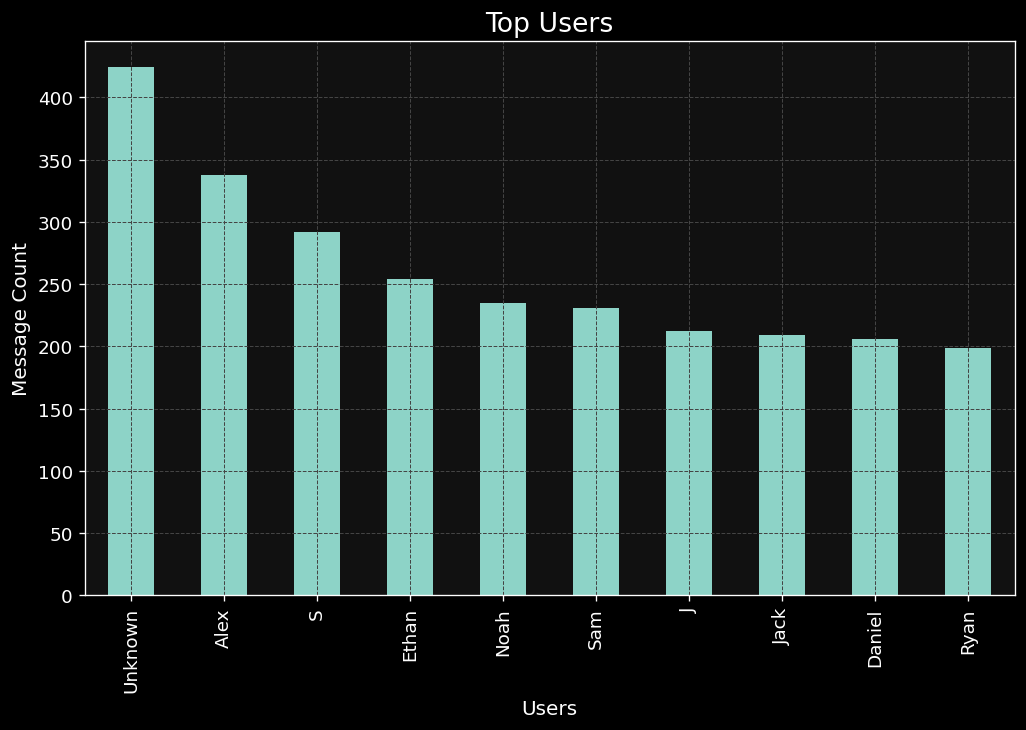

In [13]:
df['name'].value_counts().head(10).plot(kind='bar')

plt.xlabel('Users')
plt.ylabel('Message Count')
plt.title('Top Users')
plt.show()

## **Color Distribution**

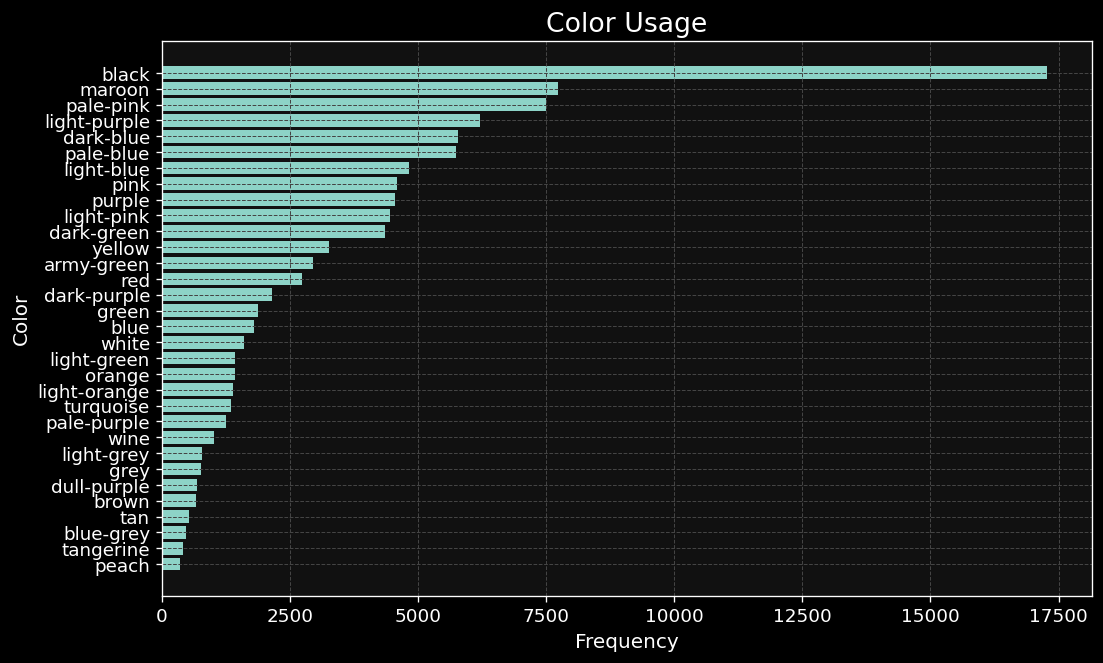

In [35]:
color_counts = df['color'].value_counts().sort_values(ascending=True)

plt.barh(color_counts.index, color_counts.values)

plt.xlabel('Frequency')
plt.ylabel('Color')
plt.title('Color Usage')

plt.show()

## **Message Length Analysis**

In [26]:
df['char_count'] = df['message'].astype(str).apply(len)

df['word_count'] = df['message'].astype(str).apply(lambda x: len(x.split()))

In [27]:
df[['char_count', 'word_count']].describe()

,char_count,word_count
count,102017.000000,102017.000000
mean,67.506533,14.409393
std,25.333793,5.402158
min,3.000000,1.000000
25%,48.000000,10.000000
50%,72.000000,15.000000
75%,90.000000,19.000000
max,100.000000,32.000000


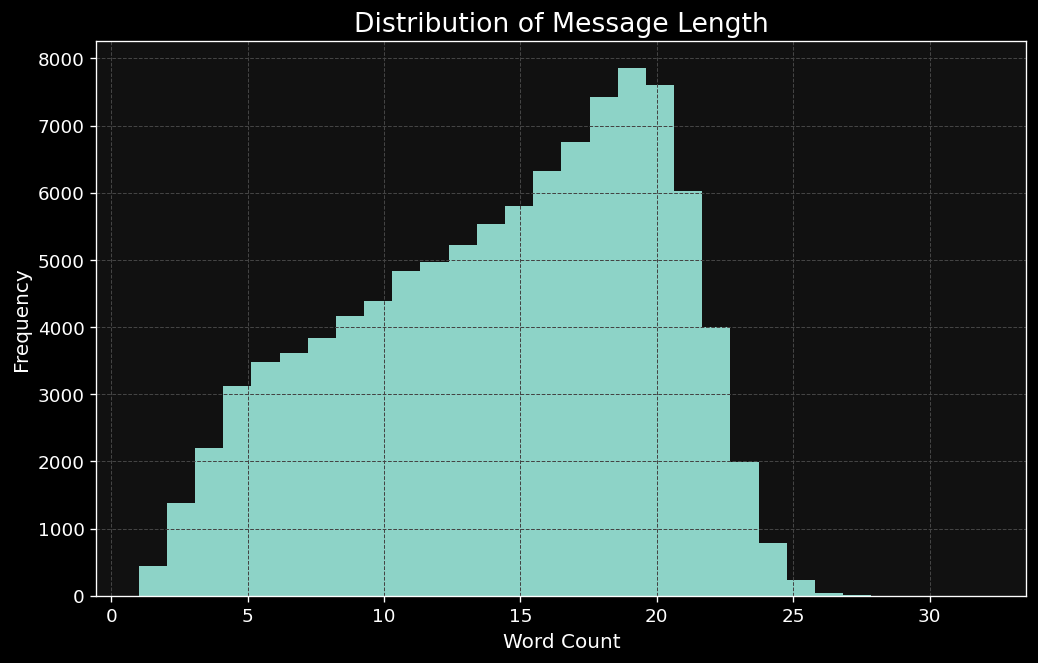

In [28]:
df['word_count'].plot(kind='hist', bins=30)

plt.xlabel('Word Count')
plt.title('Distribution of Message Length')
plt.show()

## **Most Common Words**

In [31]:
from collections import Counter

words = ' '.join(df['message'].astype(str)).lower().split()

common_words = Counter(words).most_common(20)

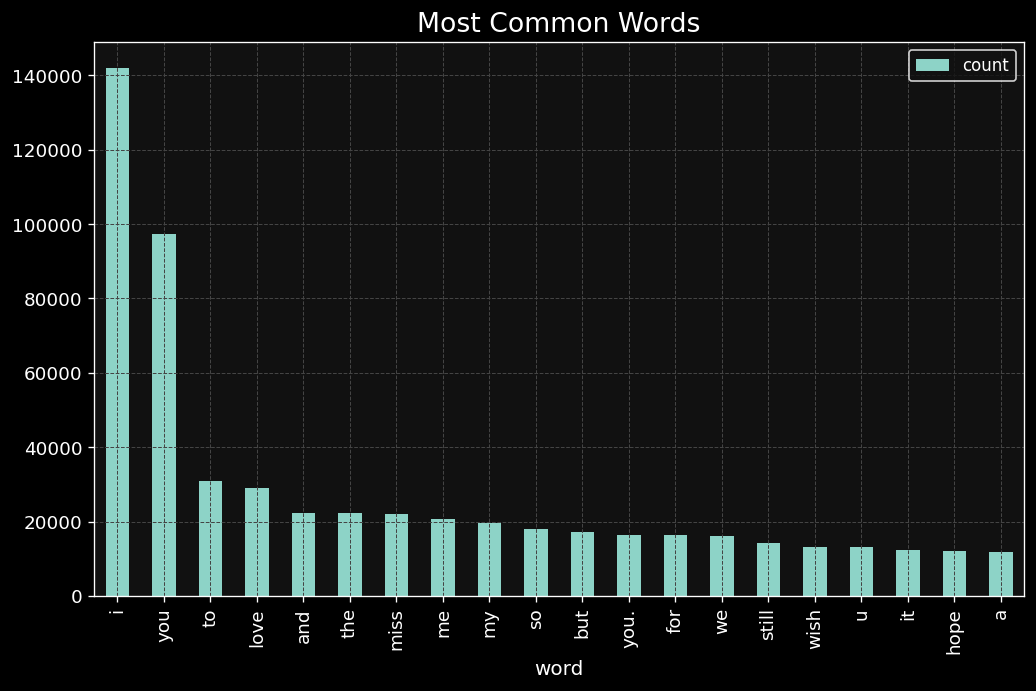

In [32]:
common_df = pd.DataFrame(common_words, columns=['word', 'count'])

common_df.plot(x='word', y='count', kind='bar')

plt.title('Most Common Words')
plt.show()

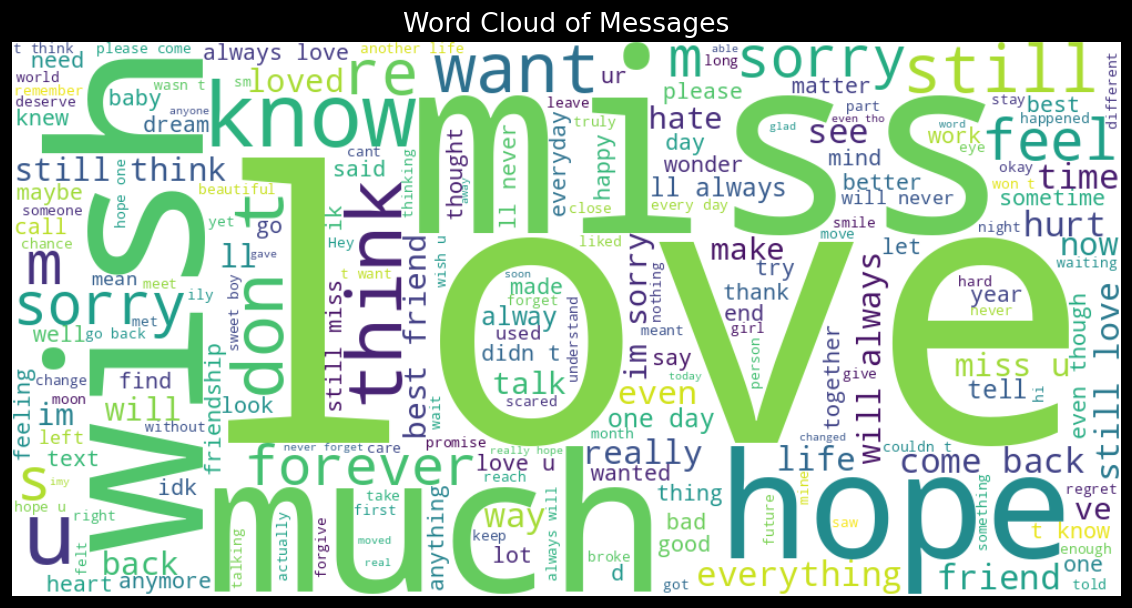

In [37]:
from wordcloud import WordCloud

text = ' '.join(df['message'].astype(str))

# Generate wordcloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Messages')

plt.show()